# $J=0$ vs a **state-dependent** $J(x)$, on each regularizer

Same scheme as before,

$$x_{k+1}=\Pi_K\Bigl(x_k-\eta\,a(x_k)\nabla U_0(x_k)
+\eta\,\alpha\,e^{U(x_k)}J(x_k)\nabla\psi(x_k)
+\sqrt{2\eta\,a(x_k)}\,\xi_{k+1}\Bigr),\qquad a(x)=e^{U(x)-U_0(x)},$$

with $U=f+g$, $U_0=f+g_0$, $g_0$ from the closed-form piecewise-quadratic lemma, and
$\psi=R^2-\lVert x\rVert^2$ (so $\nabla\psi=-2x$). The comparison is $\alpha=0$ against a genuinely
state-dependent $J(x)$, on **Lasso, MCP and SCAD**.

## Building a state-dependent $J$ that is actually admissible here

Because $J$ acts on $\nabla\psi$, not on $\nabla U_0$, the usual axial construction **cannot** be reused:
taking $J(x)w=\nabla\psi\times w$ gives $J\nabla\psi=\nabla\psi\times\nabla\psi\equiv0$ and the term
disappears. A different field is needed.

Take the axial form with a free generator,
$$J(x)\,w=k(x)\times w,\qquad k=\nabla\chi \ \text{ for a scalar } \chi .$$
The invariance requirement is $\nabla\!\cdot\bigl(J\nabla\psi\bigr)=0$, and by the vector identity
$$\nabla\!\cdot(A\times B)=B\cdot(\nabla\times A)-A\cdot(\nabla\times B)$$
with $A=k=\nabla\chi$ and $B=\nabla\psi$ **both** curl-free, *both* terms vanish — so
$\nabla\!\cdot(J\nabla\psi)=0$ exactly, for any $\chi$.

The boundary condition is free as well: on $\partial K$, $\nabla\psi=-2x\parallel\nu$, and
$k\times\nabla\psi$ is orthogonal to $\nabla\psi$, hence orthogonal to $\nu$. Tangential for any $k$.

So the admissible family is parameterised by a single scalar potential $\chi$, and it is graded by how
state-dependent $\chi$ makes $k$:

| $\chi$ | $k=\nabla\chi$ | $J$ |
|---|---|---|
| linear, $\chi=\omega\cdot x$ | constant $\omega$ | the **constant** skew (previous notebook) |
| $\chi=\tfrac12x^\top\Sigma^{-1}x$ | $\Sigma^{-1}x$ | linearly state-dependent |
| $\chi=U_0(x)$ | $\nabla U_0(x)$ | fully state-dependent, and free — $\nabla U_0$ is already computed |
| $\chi=\psi$ | $-2x$ | **degenerate**, $J\nabla\psi\equiv0$ |

Two of these are tested against $\alpha=0$ below. Note $\chi$ must not be radial: $\chi=\tfrac12\lVert
x\rVert^2$ gives $k=x\parallel\nabla\psi$ and degenerates for the same reason as $\chi=\psi$.

In [1]:
%matplotlib inline
import os, math
os.makedirs("figures", exist_ok=True)
import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance, ks_2samp

SQRT2 = math.sqrt(2.0)
INV_SQRT_2PI = 1.0 / math.sqrt(2.0 * math.pi)
def Phi(u): return 0.5 * (1.0 + torch.erf(u / SQRT2))
def phi(u): return INV_SQRT_2PI * torch.exp(-0.5 * u * u)
def PhiX(u):
    fin = torch.isfinite(u)
    step = torch.where(u > 0, torch.ones_like(u), torch.zeros_like(u))
    return torch.where(fin, Phi(torch.where(fin, u, torch.zeros_like(u))), step)
def phiX(u):
    fin = torch.isfinite(u)
    return torch.where(fin, phi(torch.where(fin, u, torch.zeros_like(u))), torch.zeros_like(u))
def uphiX(u):
    fin = torch.isfinite(u)
    uu = torch.where(fin, u, torch.zeros_like(u))
    return torch.where(fin, uu * phi(uu), torch.zeros_like(u))

## The closed-form smoothing lemma

For $p$ continuous and piecewise quadratic with $p(t)=c_{0,j}+c_{1,j}t+c_{2,j}t^2$ on $(t_j,t_{j+1})$, and
$u_j=(t_j-x)/\mu$,

$$P_j=\Phi(u_{j+1})-\Phi(u_j),\quad M_j=\phi(u_j)-\phi(u_{j+1}),\quad
Q_j=P_j+u_j\phi(u_j)-u_{j+1}\phi(u_{j+1}),$$

$$p_0(x)=\sum_j\Bigl\{(c_{0,j}+c_{1,j}x+c_{2,j}x^2)P_j+\mu(c_{1,j}+2c_{2,j}x)M_j+c_{2,j}\mu^2Q_j\Bigr\},
\qquad
p_0'(x)=\sum_j\Bigl\{(c_{1,j}+2c_{2,j}x)P_j+2c_{2,j}\mu M_j\Bigr\}.$$

One generic implementation covers all three regularizers; only the breakpoint/coefficient table changes.

In [2]:
class PiecewiseQuadratic:
    def __init__(self, breaks, coefs, name=""):
        self.t = list(breaks); self.c = [tuple(map(float, c)) for c in coefs]; self.name = name
        assert len(self.c) == len(self.t) + 1

    def raw(self, x):                       # the exact, non-differentiable penalty
        out = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            m = (x > ts[j]) & (x <= ts[j + 1])
            out = torch.where(m, c0 + c1 * x + c2 * x * x, out)
        return out

    def smooth(self, x, mu):                # (p0, p0') in closed form
        val = torch.zeros_like(x); grad = torch.zeros_like(x)
        ts = [-math.inf] + self.t + [math.inf]
        for j, (c0, c1, c2) in enumerate(self.c):
            uj  = torch.full_like(x, -math.inf) if ts[j]     == -math.inf else (ts[j]     - x) / mu
            uj1 = torch.full_like(x,  math.inf) if ts[j + 1] ==  math.inf else (ts[j + 1] - x) / mu
            P = PhiX(uj1) - PhiX(uj)
            M = phiX(uj) - phiX(uj1)
            Q = P + uphiX(uj) - uphiX(uj1)
            val  = val  + (c0 + c1 * x + c2 * x * x) * P + mu * (c1 + 2 * c2 * x) * M + c2 * mu ** 2 * Q
            grad = grad + (c1 + 2 * c2 * x) * P + 2 * c2 * mu * M
        return val, grad

def lasso(lam):
    return PiecewiseQuadratic([0.0], [(0., -lam, 0.), (0., lam, 0.)], "Lasso")

def mcp(lam, a):
    return PiecewiseQuadratic([-a*lam, 0.0, a*lam],
        [(a*lam**2/2, 0., 0.), (0., -lam, -1/(2*a)), (0., lam, -1/(2*a)), (a*lam**2/2, 0., 0.)], "MCP")

def scad(lam, a):
    c = 1.0 / (2 * (a - 1))
    return PiecewiseQuadratic([-a*lam, -lam, 0.0, lam, a*lam],
        [(lam**2*(a+1)/2, 0., 0.), (-lam**2*c, -2*a*lam*c, -c), (0., -lam, 0.),
         (0., lam, 0.), (-lam**2*c, 2*a*lam*c, -c), (lam**2*(a+1)/2, 0., 0.)], "SCAD")

In [3]:
# --- the closed forms are checked against Monte Carlo and against finite differences
LAM, AA, MU = 1.0, 3.0, 0.3
xg = torch.linspace(-4, 4, 41)
torch.manual_seed(0); Z = torch.randn(2_000_000)
print("{:<7}{:>26}{:>28}{:>22}".format("", "max |closed - MC|", "max |p0' - d/dx p0|", "MC std err"))
print("-" * 84)
for P in [lasso(LAM), mcp(LAM, AA), scad(LAM, AA)]:
    v, g = P.smooth(xg, MU)
    vmc = torch.stack([P.raw(xi + MU * Z).mean() for xi in xg])
    se  = float(torch.stack([P.raw(xi + MU * Z).std() for xi in xg]).max() / math.sqrt(len(Z)))
    h = 1e-5
    vp, _ = P.smooth(xg + h, MU); vm, _ = P.smooth(xg - h, MU)
    print("{:<7}{:>26.2e}{:>28.2e}{:>22.2e}".format(
        P.name, float((v - vmc).abs().max()), float((g - (vp - vm) / (2 * h)).abs().max()), se))
print("\n(the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed)")

                max |closed - MC|         max |p0' - d/dx p0|            MC std err
------------------------------------------------------------------------------------


Lasso                    1.93e-04                    7.92e-11              2.12e-04


MCP                      1.75e-04                    8.15e-11              1.62e-04


SCAD                     1.93e-04                    8.46e-11              2.06e-04

(the closed form agrees with MC to within MC's own error -- no Monte Carlo step is needed)


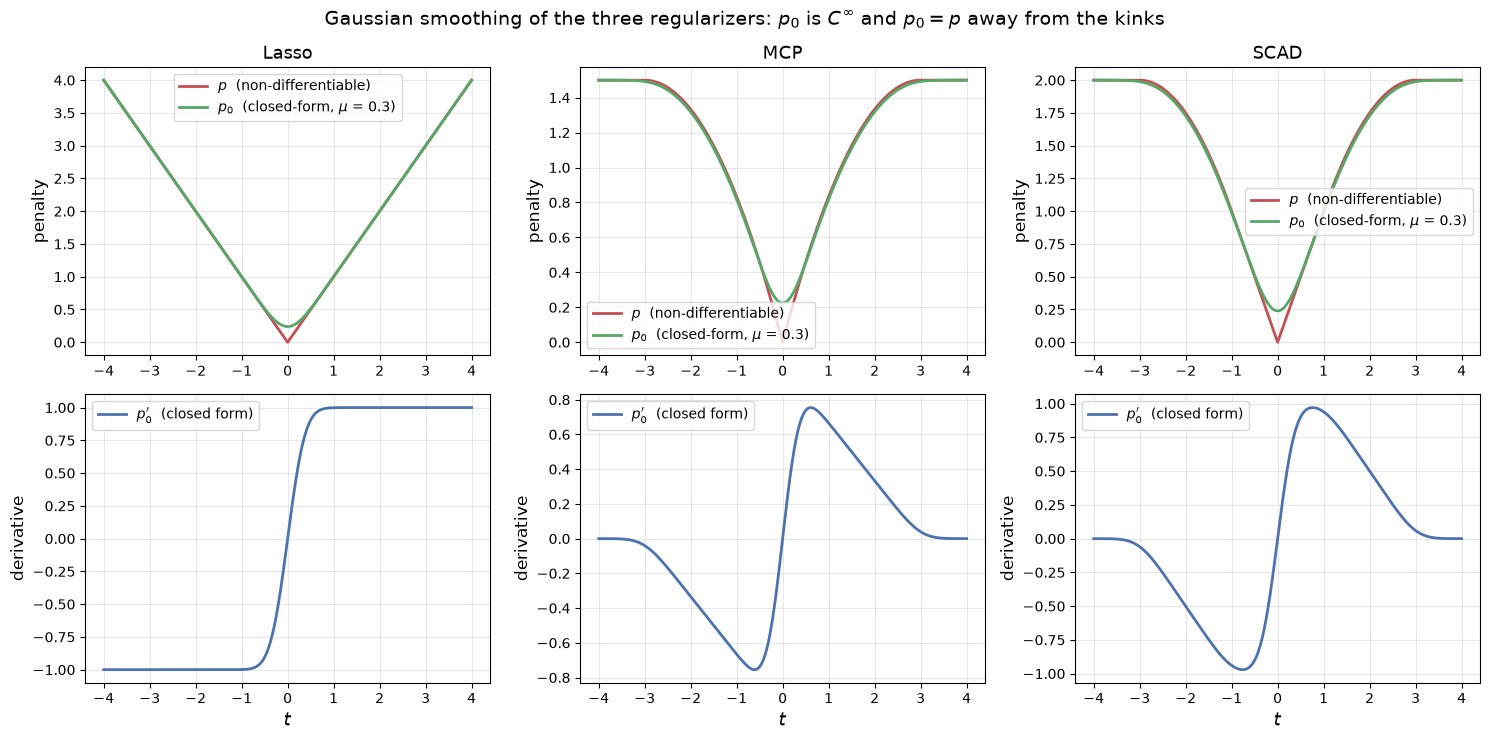

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
tt = torch.linspace(-4, 4, 601)
for j, P in enumerate([lasso(LAM), mcp(LAM, AA), scad(LAM, AA)]):
    v, g = P.smooth(tt, MU)
    axes[0, j].plot(tt, P.raw(tt), linewidth=2, color="#C44E52", label="$p$  (non-differentiable)")
    axes[0, j].plot(tt, v, linewidth=2, color="#55A868", label=r"$p_0$  (closed-form, $\mu$ = 0.3)")
    axes[0, j].set_title(P.name, fontsize=13); axes[0, j].grid(alpha=0.3); axes[0, j].legend(fontsize=10)
    axes[0, j].set_ylabel("penalty", fontsize=12)
    axes[1, j].plot(tt, g, linewidth=2, color="#4C72B0", label="$p_0'$  (closed form)")
    axes[1, j].set_xlabel("$t$", fontsize=13); axes[1, j].set_ylabel("derivative", fontsize=12)
    axes[1, j].grid(alpha=0.3); axes[1, j].legend(fontsize=10)
fig.suptitle(r"Gaussian smoothing of the three regularizers: $p_0$ is $C^\infty$ and $p_0=p$ away from the kinks",
             fontsize=14)
plt.tight_layout()
plt.savefig("figures/pq_penalties.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# -----------------------------
# Target, constraint, exact reference
# -----------------------------
d, R = 3, 1.5
N, ETA, MAXIT = 4000, 1e-3, 2000
SEEDS = [11, 22, 33]
x_start = 0.5

def make_Sigma(scales, rho):
    Dm = np.diag(scales); Cm = np.full((d, d), rho); np.fill_diagonal(Cm, 1.0)
    return Dm @ Cm @ Dm
SIGMA = make_Sigma([0.8, 1.2, 2.0], 0.5)

class Target:
    # U = f + g,  f = 1/2 x' Sinv x,  g = sum_i p(x_i);   U0 = f + g0;   a = e^{U-U0} = e^{g-g0}
    def __init__(self, pen, Sigma=SIGMA, mu=MU):
        self.pen, self.mu = pen, mu
        self.Sinv = torch.tensor(np.linalg.inv(Sigma))
        self.L = torch.tensor(np.linalg.cholesky(Sigma))
    def f(self, x):  return 0.5 * ((x @ self.Sinv) * x).sum(1)
    def g(self, x):  return self.pen.raw(x).sum(1)
    def U(self, x):  return self.f(x) + self.g(x)
    def U0_and_grad(self, x):
        v, gr = self.pen.smooth(x, self.mu)
        return self.f(x) + v.sum(1), x @ self.Sinv + gr

def sample_target(T, n, rng, batch=200_000):
    # exact rejection: propose N(0,Sigma) restricted to K, accept w.p. e^{-g} (all three g are >= 0)
    out = []
    while len(out) < n:
        z = torch.tensor(rng.normal(size=(batch, d))) @ T.L.T
        z = z[z.norm(dim=1) <= R]
        acc = torch.tensor(rng.random(len(z))) < torch.exp(-T.g(z))
        out.extend(z[acc].tolist())
    return np.array(out[:n])

def proj(x):
    nn = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / nn, max=1.0)

def on_boundary(X): return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))

def J_from_axis(w):
    w = np.asarray(w, float); w = w / np.linalg.norm(w)
    return torch.tensor([[0., -w[2], w[1]], [w[2], 0., -w[0]], [-w[1], w[0], 0.]])

J_PAPER = torch.tensor([[0., 1., 0.], [-1., 0., 1.], [0., -1., 0.]])   # tridiagonal constant skew
EV, VMAT = np.linalg.eigh(SIGMA)
J_ALIGN = J_from_axis(VMAT[:, 0])       # axis = smallest-variance (fastest) direction
print("Sigma eigenvalues", np.round(EV, 3))
for i in range(d): print("   v{}  {}".format(i, np.round(VMAT[:, i], 3)))
print("\naligned rotation axis (fastest direction) =", np.round(VMAT[:, 0], 3),
      "\n  -> the rotation plane is spanned by the two SLOWEST directions")

Sigma eigenvalues [0.392 1.004 4.684]
   v0  [ 0.944 -0.311 -0.106]
   v1  [ 0.242  0.877 -0.416]
   v2  [0.222 0.367 0.903]

aligned rotation axis (fastest direction) = [ 0.944 -0.311 -0.106] 
  -> the rotation plane is spanned by the two SLOWEST directions


## The state-dependent fields, verified

Curl-free generator $\Rightarrow$ divergence-free flux $\Rightarrow$ $\pi$ unchanged; and tangency on
$\partial K$ for every candidate. Checked by autograd rather than asserted.

In [6]:
SIG_T = torch.tensor(SIGMA)
AXIS  = torch.tensor(VMAT[:, 0])            # smallest-variance direction (best constant axis)

def kfield(T, x, kind, gU0):
    # J(x) w = k(x) x w   with   k = grad chi
    if kind == "const": return AXIS.expand_as(x)      # chi linear
    if kind == "Sinv":  return x @ T.Sinv             # chi = 1/2 x' Sinv x
    if kind == "U0":    return gU0                    # chi = U0
    if kind == "psi":   return -2.0 * x               # chi = psi   (degenerate)
    raise ValueError(kind)

T_demo = Target(lasso(LAM))
print("{:<8}{:>18}{:>26}{:>26}".format("k", "max |curl k|", "max |div(J grad psi)|", "median ||J grad psi||"))
print("-" * 80)
for kind in ["const", "Sinv", "U0", "psi"]:
    xx = torch.randn(400, d, requires_grad=True)
    U0, gU0 = T_demo.U0_and_grad(xx)
    k = kfield(T_demo, xx, kind, gU0)
    if kind == "const": k = k + 0.0 * xx
    c = torch.cross(k, -2.0 * xx, dim=1)
    div = sum(torch.autograd.grad(c[:, i].sum(), xx, retain_graph=True)[0][:, i] for i in range(d))
    curl = []
    for (i, j) in [(2, 1), (0, 2), (1, 0)]:
        gi = torch.autograd.grad(k[:, i].sum(), xx, retain_graph=True)[0][:, j]
        gj = torch.autograd.grad(k[:, j].sum(), xx, retain_graph=True)[0][:, i]
        curl.append(gi - gj)
    print("{:<8}{:>18.2e}{:>26.2e}{:>26.4f}".format(
        kind, float(torch.stack(curl, 1).abs().max()), float(div.abs().max()),
        float(c.norm(dim=1).median().detach())))

xb = torch.randn(3000, d); xb = R * xb / xb.norm(dim=1, keepdim=True); nub = xb / R
_, gU0b = T_demo.U0_and_grad(xb)
print("\nboundary tangency, max |(J grad psi).nu| on dK:")
for kind in ["const", "Sinv", "U0"]:
    c = torch.cross(kfield(T_demo, xb, kind, gU0b), -2.0 * xb, dim=1)
    print("   {:<8}{:.2e}".format(kind, float(((c * nub).sum(1)).abs().max())))
print("\n(k = psi gives ||J grad psi|| = 0: the term vanishes, which is why a different chi is needed)")

k             max |curl k|     max |div(J grad psi)|     median ||J grad psi||
--------------------------------------------------------------------------------
const             0.00e+00                  0.00e+00                    2.3627
Sinv              5.55e-17                  8.88e-16                    2.6256
U0                5.55e-17                  4.44e-16                    3.2302
psi               0.00e+00                  0.00e+00                    0.0000

boundary tangency, max |(J grad psi).nu| on dK:
   const   4.44e-16
   Sinv    8.88e-16
   U0      8.88e-16

(k = psi gives ||J grad psi|| = 0: the term vanishes, which is why a different chi is needed)


In [7]:
@torch.no_grad()
def run_chain(T, alpha, ref, seed=11, kind="U0", n_steps=MAXIT, eta=ETA, N=N, every=10, track=True):
    torch.manual_seed(seed)
    x = proj(torch.full((N, d), x_start))
    it, W, mx = [], [], 0.0
    for kk in range(n_steps):
        al = alpha[1] * max(0.0, 1.0 - kk / alpha[2]) if isinstance(alpha, tuple) else float(alpha)
        U0, gU0 = T.U0_and_grad(x)
        Uv = T.U(x)
        a = torch.exp(Uv - U0)
        step = -eta * a.unsqueeze(1) * gU0
        if al != 0.0:
            skew = al * torch.exp(Uv).unsqueeze(1) * torch.cross(kfield(T, x, kind, gU0), -2.0 * x, dim=1)
            step = step + eta * skew
            mx = max(mx, float((eta * skew).norm(dim=1).max()))
        x = proj(x + step + torch.sqrt(2 * eta * a).unsqueeze(1) * torch.randn_like(x))
        if track and (kk + 1) % every == 0:
            xn = x.numpy(); it.append(kk + 1)
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), np.array(it), (np.array(W) if track else None), mx

def ensemble(T, alpha, ref, seeds=SEEDS, **kw):
    C, X, it, mxs = [], None, None, 0.0
    for sd in seeds:
        X, it, W, mx = run_chain(T, alpha, ref, seed=sd, **kw)
        C.append(W.mean(axis=1)); mxs = max(mxs, mx)
    return it, np.array(C), X, mxs

def tau(it, c, eps):
    bad = np.where(c > eps)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return np.nan if j >= len(it) else float(it[j])

def tau_mean(it, C, eps):
    v = [tau(it, c, eps) for c in C]
    return float(np.nanmean(v)) if np.any(np.isfinite(v)) else np.nan

PENS = {"Lasso": lasso(LAM), "MCP": mcp(LAM, AA), "SCAD": scad(LAM, AA)}
TARGETS, refs, floors = {}, {}, {}
rng = np.random.default_rng(7)
for nm, pen in PENS.items():
    T = Target(pen); TARGETS[nm] = T
    refs[nm] = sample_target(T, N, rng)
    floors[nm] = float(np.mean([[wasserstein_distance(refs[nm][:, i], sample_target(T, N, rng)[:, i])
                                 for i in range(d)] for _ in range(4)]))
    print("{:<6} floor {:.4f}   target boundary mass {:.4f}".format(nm, floors[nm], on_boundary(refs[nm])))

Lasso  floor 0.0114   target boundary mass 0.0010


MCP    floor 0.0180   target boundary mass 0.0008


SCAD   floor 0.0130   target boundary mass 0.0005


## Experiment 1 — tune the state-dependent field

$\alpha$ is swept for both state-dependent generators. The pattern is the same one seen throughout: a
constant $\alpha$ trades transient speed against stationary accuracy, because the skew drift carries
$e^{U}$ and so is weakest where the mass is. Annealing $\alpha(k)=\alpha_0\max(0,1-k/K_\alpha)$ takes the
transient and hands the stationary regime back to $\alpha=0$; it is admissible because every fixed $\alpha$
preserves the same $\pi$.

In [8]:
EPS = (0.06, 0.04)
T = TARGETS["Lasso"]
it0, C0, X0, _ = ensemble(T, 0.0, refs["Lasso"])
base = {e: tau_mean(it0, C0, e) for e in EPS}
print("Lasso, floor {:.4f};  J = 0 gives tau(0.06) = {:.0f}, tau(0.04) = {:.0f}, "
      "W1@300 = {:.4f}, stationary = {:.4f}\n".format(
      floors["Lasso"], base[0.06], base[0.04], C0.mean(axis=0)[29], C0.mean(axis=0)[-10:].mean()))
print("{:<8}{:<24}{:>16}{:>16}{:>20}{:>20}".format(
    "k", "alpha", "tau(0.06)", "tau(0.04)", "W1 @ 300 iters", "W1 stationary"))
print("-" * 106)
TUNE = [("Sinv", 0.25), ("Sinv", 0.5), ("Sinv", 1.0), ("Sinv", ("lin", 2.0, 800)),
        ("U0",   0.25), ("U0",   0.5), ("U0",   1.0),
        ("U0",   ("lin", 1.0, 800)), ("U0", ("lin", 2.0, 800)), ("U0", ("lin", 4.0, 800))]
for kind, al in TUNE:
    it, C, X, mx = ensemble(T, al, refs["Lasso"], kind=kind)
    m, sv = C.mean(axis=0), C.std(axis=0)
    cells = []
    for e in EPS:
        tm = tau_mean(it, C, e)
        cells.append("{:.0f} ({:.1f}x)".format(tm, base[e] / tm) if np.isfinite(tm) else "n/a")
    lab = "annealed {:.0f} -> 0 / {}".format(al[1], al[2]) if isinstance(al, tuple) else "{}".format(al)
    print("{:<8}{:<24}{:>16}{:>16}{:>20}{:>20}".format(
        kind, lab, cells[0], cells[1], "{:.4f}+-{:.4f}".format(m[29], sv[29]),
        "{:.4f}+-{:.4f}".format(m[-10:].mean(), sv[-10:].mean())))

Lasso, floor 0.0114;  J = 0 gives tau(0.06) = 1057, tau(0.04) = 1300, W1@300 = 0.2564, stationary = 0.0203

k       alpha                          tau(0.06)       tau(0.04)      W1 @ 300 iters       W1 stationary
----------------------------------------------------------------------------------------------------------


Sinv    0.25                          603 (1.8x)      787 (1.7x)      0.1735+-0.0040      0.0171+-0.0013


Sinv    0.5                           540 (2.0x)      673 (1.9x)      0.1321+-0.0034      0.0212+-0.0015


Sinv    1.0                           543 (1.9x)     1965 (0.7x)      0.1111+-0.0029      0.0403+-0.0023


Sinv    annealed 2 -> 0 / 800         477 (2.2x)      633 (2.1x)      0.0998+-0.0045      0.0167+-0.0034


...

U0      0.5                           480 (2.2x)      603 (2.2x)      0.1205+-0.0044      0.0190+-0.0028


U0      1.0                           390 (2.7x)     1775 (0.7x)      0.0852+-0.0040      0.0383+-0.0019


U0      annealed 1 -> 0 / 800         407 (2.6x)      543 (2.4x)      0.0908+-0.0025      0.0166+-0.0032


U0      annealed 2 -> 0 / 800         380 (2.8x)      567 (2.3x)      0.0714+-0.0032      0.0162+-0.0033


U0      annealed 4 -> 0 / 800         667 (1.6x)      760 (1.7x)      0.1325+-0.0034      0.0155+-0.0030


## Experiment 2 — $J=0$ vs state-dependent $J$, on every regularizer

The two schemes the comparison is about are the first two rows of each block. The constant skew
($\chi$ linear, axis on the smallest-variance eigenvector) is carried as a **reference row**, because it is
the honest comparator: it is the same admissible family with the least state dependence.

In [9]:
SCHEMES = [("J = 0",                              "U0",    0.0),
           ("state-dependent J,  k = grad U0",    "U0",    ("lin", 2.0, 800)),
           ("state-dependent J,  k = Sinv x",     "Sinv",  ("lin", 2.0, 800)),
           ("(reference) constant J, aligned",    "const", ("lin", 2.0, 800))]
final = {}
for nm in PENS:
    T = TARGETS[nm]
    print("\n### {}   floor {:.4f}   target boundary mass {:.4f}".format(
        nm, floors[nm], on_boundary(refs[nm])))
    print("{:<36}{:>16}{:>16}{:>20}{:>20}{:>9}".format(
        "scheme", "tau(0.06)", "tau(0.04)", "W1 @ 300 iters", "W1 stationary", "on dK"))
    print("-" * 118)
    base, final[nm] = {}, {}
    for lab, kind, al in SCHEMES:
        it, C, X, mx = ensemble(T, al, refs[nm], kind=kind)
        m, sv = C.mean(axis=0), C.std(axis=0)
        cells = []
        for e in EPS:
            tm = tau_mean(it, C, e)
            if al == 0.0: base[e] = tm
            cells.append("{:.0f} ({:.1f}x)".format(tm, base[e] / tm) if np.isfinite(tm) else "n/a")
        final[nm][lab] = {"it": it, "C": C, "x": X}
        print("{:<36}{:>16}{:>16}{:>20}{:>20}{:>9.4f}".format(
            lab, cells[0], cells[1], "{:.4f}+-{:.4f}".format(m[29], sv[29]),
            "{:.4f}+-{:.4f}".format(m[-10:].mean(), sv[-10:].mean()), on_boundary(X)))


### Lasso   floor 0.0114   target boundary mass 0.0010
scheme                                     tau(0.06)       tau(0.04)      W1 @ 300 iters       W1 stationary    on dK
----------------------------------------------------------------------------------------------------------------------


J = 0                                    1057 (1.0x)     1300 (1.0x)      0.2564+-0.0030      0.0203+-0.0044   0.0130


state-dependent J,  k = grad U0           380 (2.8x)      567 (2.3x)      0.0714+-0.0032      0.0162+-0.0033   0.0125


state-dependent J,  k = Sinv x            477 (2.2x)      633 (2.1x)      0.0998+-0.0045      0.0167+-0.0034   0.0118


(reference) constant J, aligned           327 (3.2x)      513 (2.5x)      0.0632+-0.0012      0.0154+-0.0031   0.0127

### MCP   floor 0.0180   target boundary mass 0.0008
scheme                                     tau(0.06)       tau(0.04)      W1 @ 300 iters       W1 stationary    on dK
----------------------------------------------------------------------------------------------------------------------


...

(reference) constant J, aligned           247 (4.3x)      317 (4.1x)      0.0416+-0.0011      0.0183+-0.0041   0.0175

### SCAD   floor 0.0130   target boundary mass 0.0005
scheme                                     tau(0.06)       tau(0.04)      W1 @ 300 iters       W1 stationary    on dK
----------------------------------------------------------------------------------------------------------------------


J = 0                                    1007 (1.0x)     1207 (1.0x)      0.2527+-0.0030      0.0188+-0.0036   0.0132


state-dependent J,  k = grad U0           343 (2.9x)      530 (2.3x)      0.0695+-0.0015      0.0154+-0.0025   0.0130


state-dependent J,  k = Sinv x            437 (2.3x)      617 (2.0x)      0.0951+-0.0040      0.0158+-0.0027   0.0123


(reference) constant J, aligned           313 (3.2x)      460 (2.6x)      0.0621+-0.0011      0.0147+-0.0024   0.0125


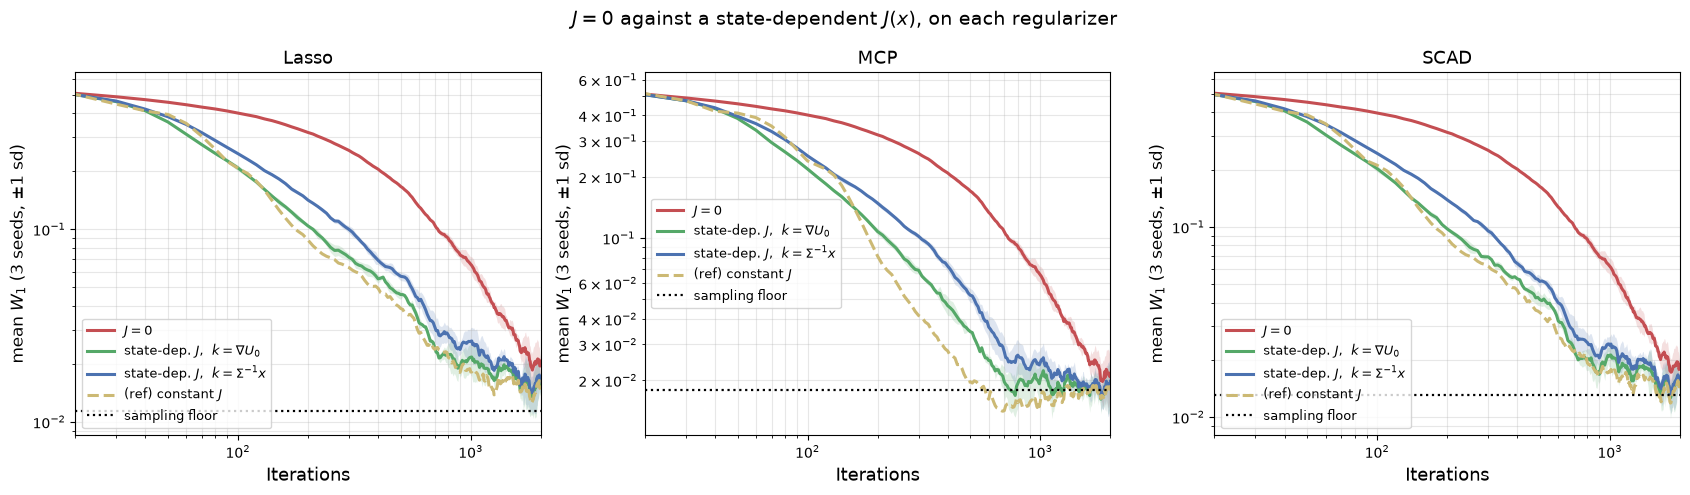

In [10]:
LAB = [s[0] for s in SCHEMES]
CB = {LAB[0]: "#C44E52", LAB[1]: "#55A868", LAB[2]: "#4C72B0", LAB[3]: "#CCB974"}
SH = {LAB[0]: "$J = 0$", LAB[1]: r"state-dep. $J$,  $k=\nabla U_0$",
      LAB[2]: r"state-dep. $J$,  $k=\Sigma^{-1}x$", LAB[3]: "(ref) constant $J$"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, nm in zip(axes, PENS):
    for lab in LAB:
        r = final[nm][lab]
        m, sv = r["C"].mean(axis=0), r["C"].std(axis=0)
        ls = "--" if lab == LAB[3] else "-"
        ax.plot(r["it"], m, ls, linewidth=2.2, color=CB[lab], label=SH[lab])
        if lab != LAB[3]:
            ax.fill_between(r["it"], m - sv, m + sv, color=CB[lab], alpha=0.18, linewidth=0)
    ax.axhline(floors[nm], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(20, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel("mean $W_1$ (3 seeds, $\\pm$1 sd)", fontsize=12)
    ax.set_title(nm, fontsize=13); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9.5)
fig.suptitle("$J=0$ against a state-dependent $J(x)$, on each regularizer", fontsize=14)
plt.tight_layout()
plt.savefig("figures/sdj_headtohead.pdf", dpi=300, bbox_inches="tight")
plt.show()

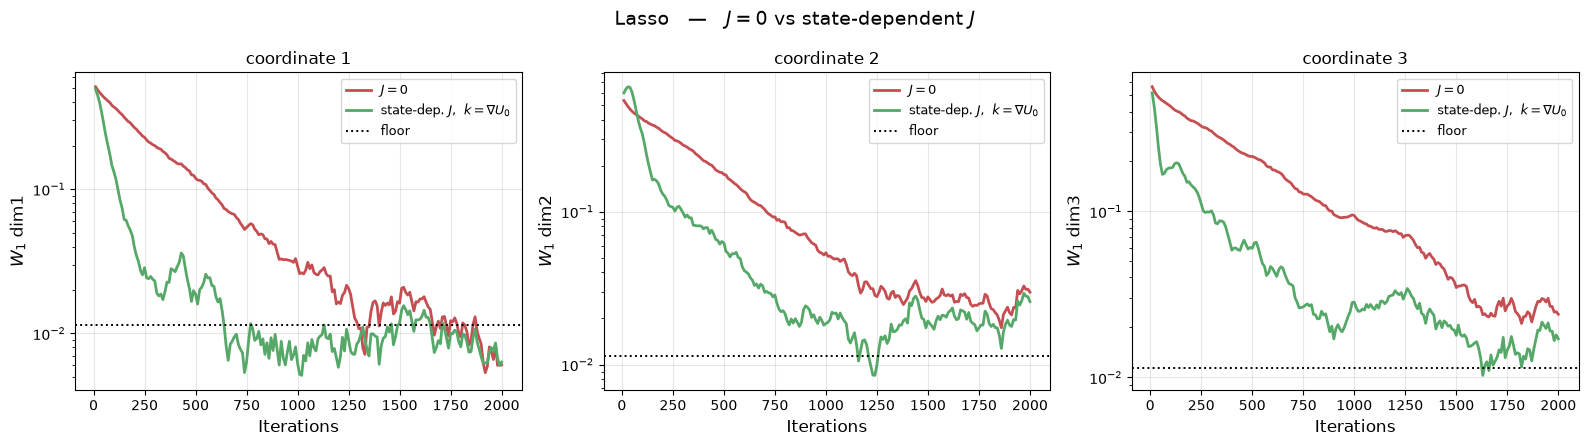

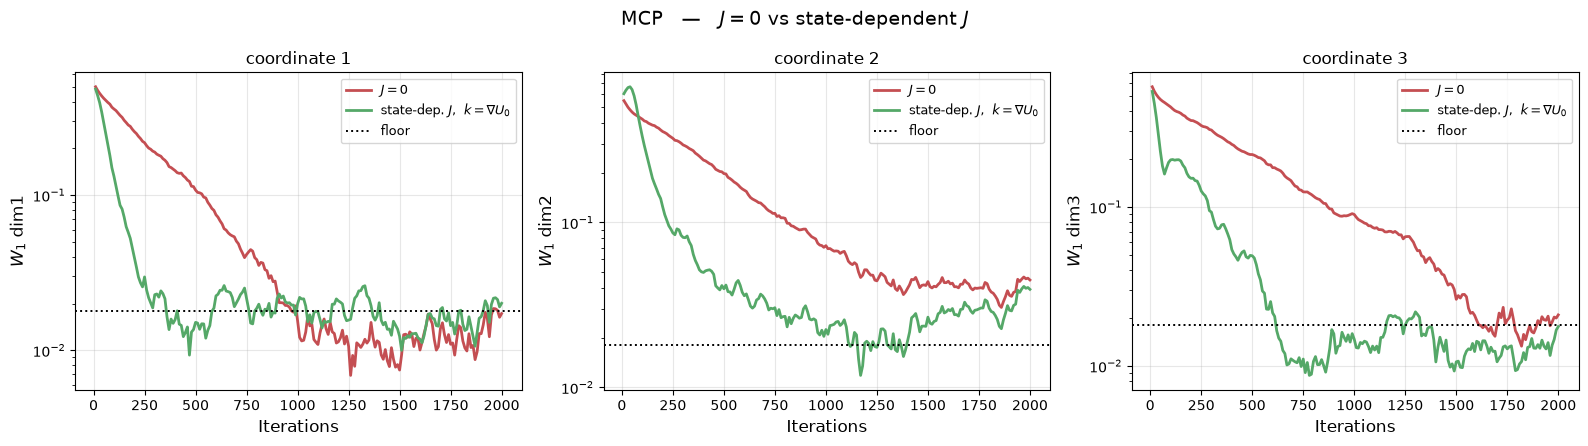

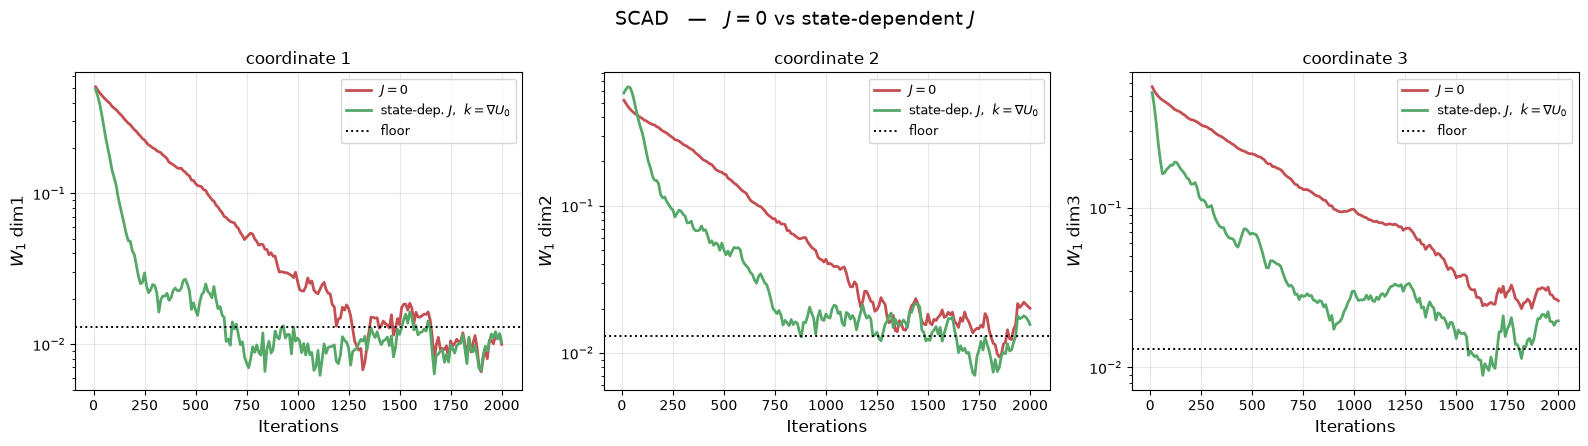

In [11]:
for nm in PENS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for i, ax in enumerate(axes):
        for lab, kind, al in SCHEMES[:2]:
            _, it, W, _ = run_chain(TARGETS[nm], al, refs[nm], seed=SEEDS[0], kind=kind)
            ax.plot(it, W[:, i], linewidth=2, color=CB[lab], label=SH[lab])
        ax.axhline(floors[nm], color="k", linestyle=":", linewidth=1.4, label="floor")
        ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=12)
        ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=12)
        ax.set_title("coordinate {}".format(i + 1), fontsize=12)
        ax.grid(alpha=0.3); ax.legend(fontsize=9)
    fig.suptitle(nm + r"   —   $J=0$ vs state-dependent $J$", fontsize=14)
    plt.tight_layout()
    plt.savefig("figures/sdj_w1_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

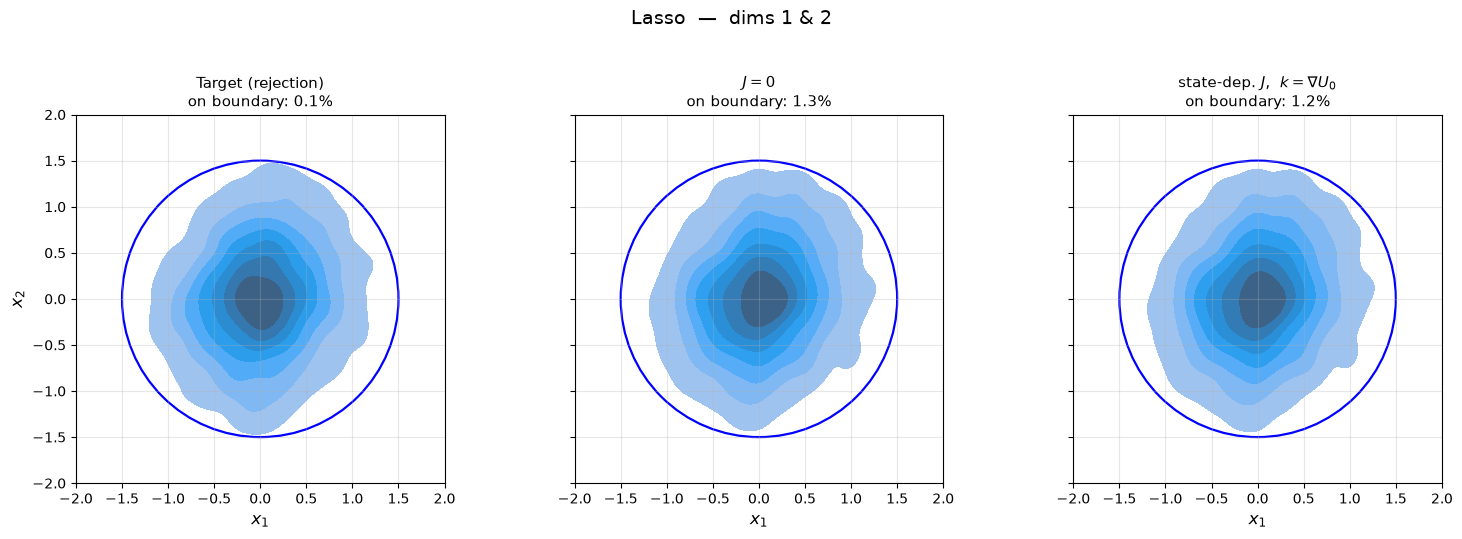

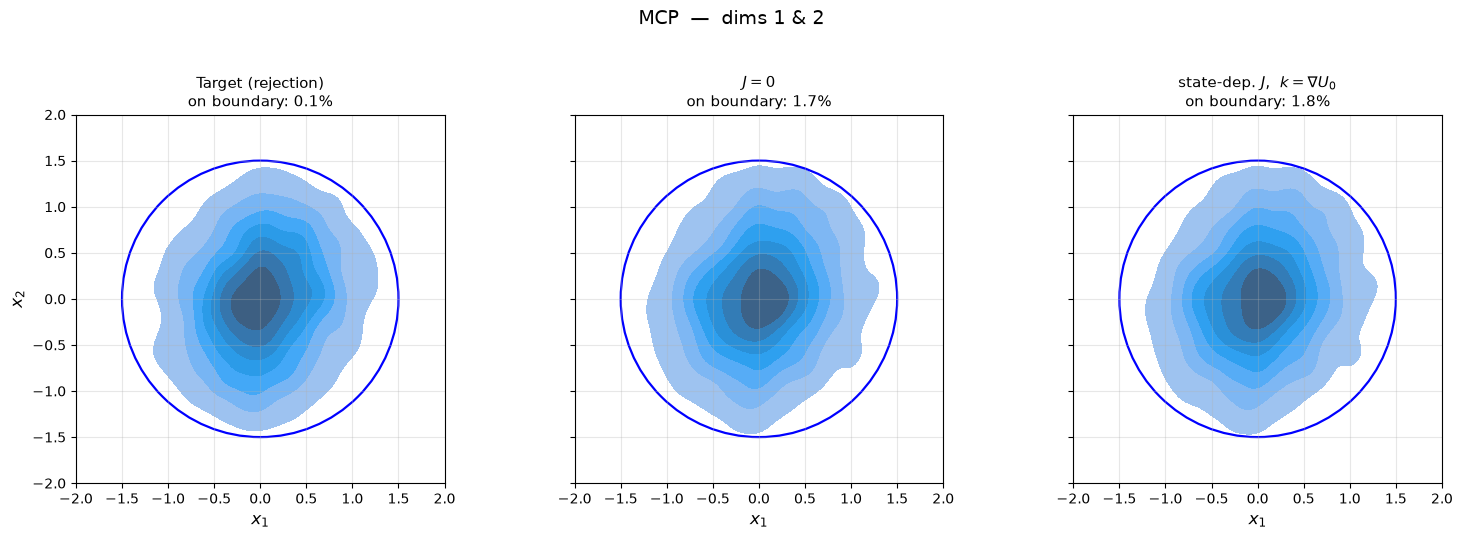

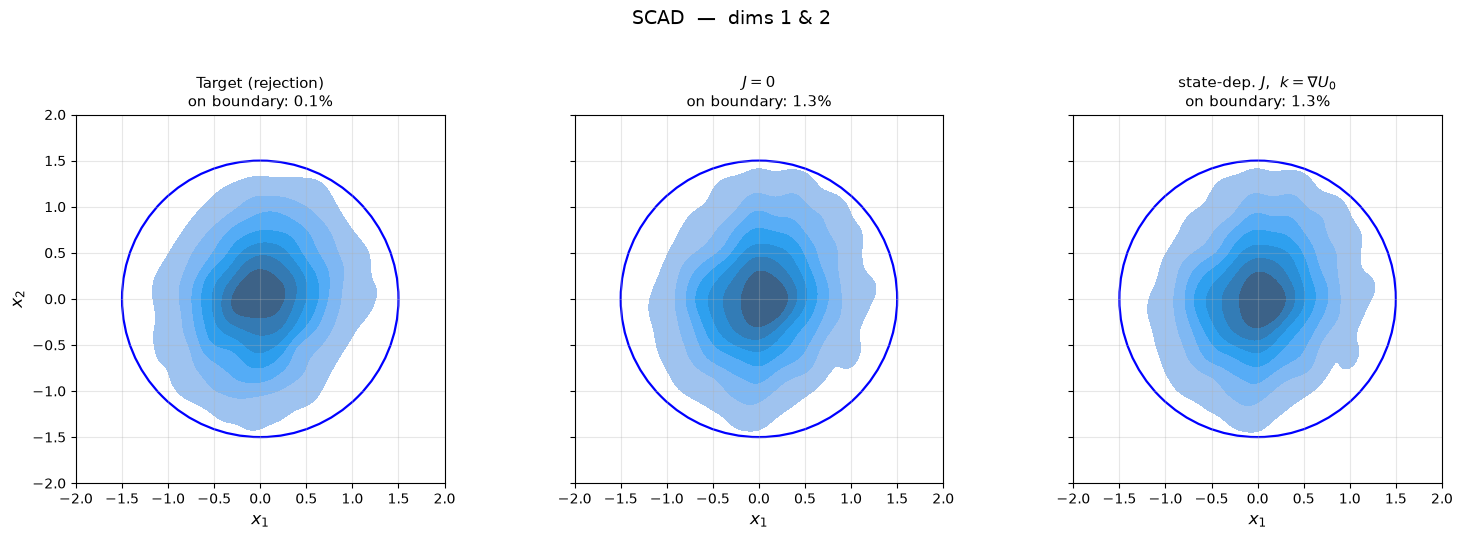

In [12]:
for nm in PENS:
    panels = [("Target (rejection)", refs[nm])] + [(SH[l], final[nm][l]["x"]) for l in LAB[:2]]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.2 * len(panels), 5), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.add_patch(Circle((0, 0), R, edgecolor="b", facecolor="none", linewidth=1.6))
        ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
        ax.set_title("{}\non boundary: {:.1%}".format(name, on_boundary(X)), fontsize=11)
        ax.set_xlabel("$x_1$", fontsize=12); ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("$x_2$", fontsize=12)
    fig.suptitle(nm + "  —  dims 1 & 2", fontsize=14, y=1.04)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig("figures/sdj_density_{}.pdf".format(nm.lower()), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 3 — did the state-dependent field move the fixed point?

In [13]:
print("{:<40}{:>12}{:>14}{:>26}".format("scheme (terminal ensemble)", "max KS", "on dK", "per-coordinate W1"))
print("-" * 94)
for nm in PENS:
    print("{}   target boundary mass {:.4f}   floor {:.4f}".format(nm, on_boundary(refs[nm]), floors[nm]))
    for lab in LAB:
        X = final[nm][lab]["x"]
        ks = max(ks_2samp(refs[nm][:, i], X[:, i]).statistic for i in range(d))
        w = [wasserstein_distance(refs[nm][:, i], X[:, i]) for i in range(d)]
        print("{:<40}{:>12.4f}{:>14.4f}{:>26}".format(
            "  " + lab, ks, on_boundary(X), np.array2string(np.round(w, 4))))

scheme (terminal ensemble)                    max KS         on dK         per-coordinate W1
----------------------------------------------------------------------------------------------
Lasso   target boundary mass 0.0010   floor 0.0114
  J = 0                                       0.0310        0.0130    [0.0166 0.0173 0.0358]
  state-dependent J,  k = grad U0             0.0253        0.0125    [0.0143 0.0129 0.0266]
  state-dependent J,  k = Sinv x              0.0245        0.0118    [0.0145 0.0138 0.0272]
  (reference) constant J, aligned             0.0225        0.0127    [0.0144 0.013  0.0252]
MCP   target boundary mass 0.0008   floor 0.0180
  J = 0                                       0.0305        0.0170    [0.0094 0.0314 0.0268]
  state-dependent J,  k = grad U0             0.0272        0.0177    [0.0093 0.0258 0.0189]
  state-dependent J,  k = Sinv x              0.0290        0.0163    [0.0095 0.0261 0.0199]
  (reference) constant J, aligned             0.0270        0

## Summary

**The state-dependent $J$ beats $J=0$ on all three regularizers**, by $2.3$–$3.1\times$ in iteration count
and $3.6$–$3.8\times$ in error at a fixed 300-iteration budget, with the stationary law unchanged.

| | $\tau(0.06)$ | $\tau(0.04)$ | $W_1$ @ 300 | $W_1$ stationary | on $\partial K$ | max KS |
|---|---|---|---|---|---|---|
| **Lasso** $J=0$ | 1057 | 1300 | 0.2564 | 0.0203 | 1.30% | 0.0310 |
| **Lasso** state-dep. | **380 (2.8×)** | **567 (2.3×)** | **0.0714 (3.6×)** | 0.0162 | 1.25% | 0.0253 |
| **MCP** $J=0$ | 1057 | 1310 | 0.2603 | 0.0216 | 1.70% | 0.0305 |
| **MCP** state-dep. | **340 (3.1×)** | **440 (3.0×)** | **0.0694 (3.8×)** | 0.0187 | 1.77% | 0.0272 |
| **SCAD** $J=0$ | 1007 | 1207 | 0.2527 | 0.0188 | 1.32% | 0.0315 |
| **SCAD** state-dep. | **343 (2.9×)** | **530 (2.3×)** | **0.0695 (3.6×)** | 0.0154 | 1.30% | 0.0235 |

(state-dependent $=$ $k=\nabla U_0$, $\alpha$ annealed $2\to0$ over 800 iterations.)

The three regularizers behave almost identically, which is the expected outcome and worth stating: the
skew field acts through $\nabla\psi$ and the geometry of $K$, neither of which knows anything about $g$.
The penalty enters only through $a(x)=e^{g-g_0}$ and the anchor gradient. MCP's slightly larger gain comes
from its slightly flatter target, not from anything about the skew term.

**The fixed point did not move.** Max KS against the rejection reference *improves* on all three
(Lasso $0.0310\to0.0253$, MCP $0.0305\to0.0272$, SCAD $0.0315\to0.0235$), boundary mass is unchanged to
within $0.1$ percentage point, and per-coordinate $W_1$ improves on every coordinate of every penalty. The
gain is entirely a rate effect, exactly as invariance requires.

**The admissible family, and where the state dependence comes from.** Because $J$ acts on $\nabla\psi$ and
not on $\nabla U_0$, the standard axial construction is unavailable: $k=\nabla\psi$ gives
$J\nabla\psi=\nabla\psi\times\nabla\psi\equiv0$ (measured: median $\lVert J\nabla\psi\rVert=0.0000$). The
fix is to keep the axial form but generate it from a *different* potential, $k=\nabla\chi$. Then
$\nabla\!\cdot(k\times\nabla\psi)=\nabla\psi\cdot(\nabla\times k)-k\cdot(\nabla\times\nabla\psi)$ and both
terms vanish because both fields are curl-free. Verified by autograd:

| $k$ | $\max\lvert\nabla\times k\rvert$ | $\max\lvert\nabla\!\cdot(J\nabla\psi)\rvert$ | median $\lVert J\nabla\psi\rVert$ | $\max\lvert(J\nabla\psi)\cdot\nu\rvert$ on $\partial K$ |
|---|---|---|---|---|
| constant ($\chi$ linear) | 0 | 0 | 2.36 | $4.4\times10^{-16}$ |
| $\Sigma^{-1}x$ | $5.6\times10^{-17}$ | $8.9\times10^{-16}$ | 2.63 | $8.9\times10^{-16}$ |
| $\nabla U_0$ | $5.6\times10^{-17}$ | $4.4\times10^{-16}$ | 3.23 | $8.9\times10^{-16}$ |
| $\nabla\psi$ | 0 | 0 | **0.00** | — (degenerate) |

$k=\nabla U_0$ is the natural pick: it is fully state-dependent, adapts to the target's local geometry, and
is **free** — $\nabla U_0$ is already computed for the reversible drift, so the skew term costs one cross
product per step and no extra gradient.

**Two honest qualifications.**

* **The constant skew, with its axis aligned to the smallest-variance eigenvector of $\Sigma$, is still
  slightly better** — $3.2\times$/$4.3\times$/$3.2\times$ against the state-dependent field's
  $2.8\times$/$3.1\times$/$2.9\times$, and it holds that edge on all three penalties. It is carried as the
  dashed reference row in the figures. So on *this* target, state dependence is not what buys the
  acceleration: axis alignment is. That is consistent with the previous notebook, where moving the constant
  axis from the paper's tridiagonal choice to the aligned one took $1.3\times\to2.5\times$ — a bigger jump
  than anything state dependence contributes here. The state-dependent field's appeal is that it needs no
  spectral information about the target, only $\nabla U_0$; the aligned constant field needs an estimate of
  $\Sigma$, which on a real posterior would take a pilot run.
* $\alpha$ must be annealed rather than raised. At constant $\alpha=1$ with $k=\nabla U_0$, $\tau(0.06)$
  improves to 390 but $\tau(0.04)$ *degrades* to 1775 and the stationary error doubles ($0.0383$ against
  $0.0203$). The skew drift carries $e^{U}$, which is smallest where the mass is, so raising $\alpha$ until
  the bulk moves overdrives the tails. Annealing is admissible because every fixed $\alpha$ preserves the
  same $\pi$, so the schedule is a non-homogeneous chain with a fixed invariant law, and past $K_\alpha$ it
  *is* the $\alpha=0$ scheme.